/tmp/ipykernel_38454/2652184877.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2023-01-01" , end="2026-03-21")
[*********************100%***********************]  1 of 1 completed


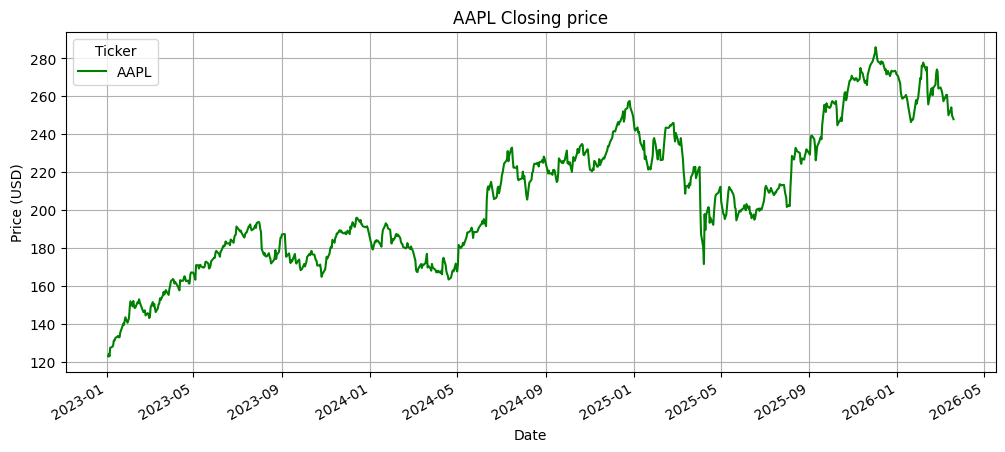

In [23]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


data = yf.download("AAPL", start="2023-01-01" , end="2026-03-21")


data['Close'].plot(figsize=(12,5), title="AAPL Closing price", color="green")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()


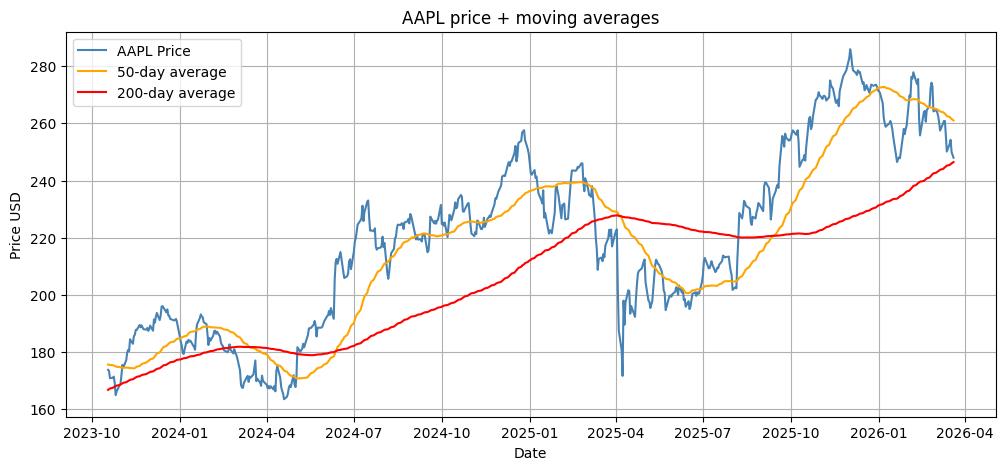

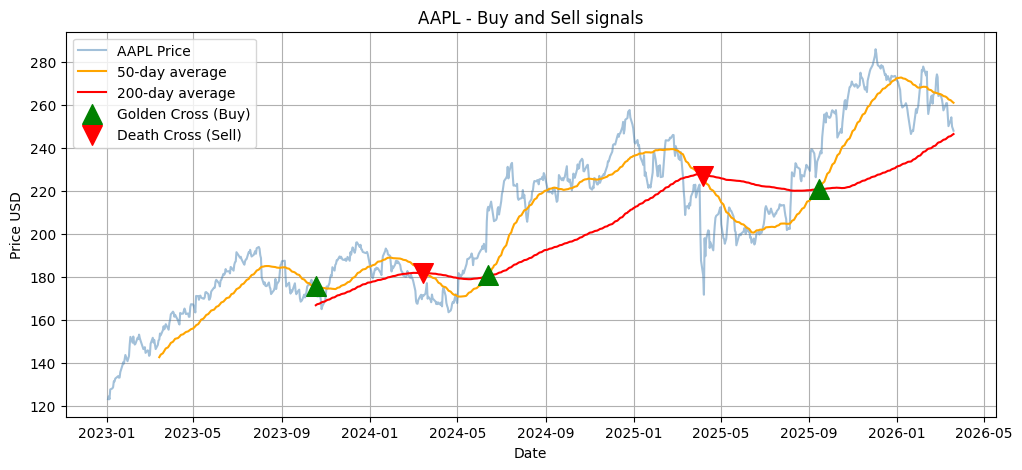

In [24]:




# Calculate moving averages
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['SMA_200'] = data['Close'].rolling(window=200).mean()

# Plot everything together, starting from where SMA_200 has valid data
plt.figure(figsize=(12, 5))
plt.plot(data.loc[data['SMA_200'].first_valid_index():]['Close'], label='AAPL Price', color='steelblue')
plt.plot(data.loc[data['SMA_200'].first_valid_index():]['SMA_50'], label='50-day average', color='orange')
plt.plot(data.loc[data['SMA_200'].first_valid_index():]['SMA_200'], label='200-day average', color='red')

plt.title("AAPL price + moving averages")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.grid(True)
plt.show()

# Find crossover points
data['Signal'] = 0
data.loc[data['SMA_50'] > data['SMA_200'], 'Signal'] = 1

# Find the exact days where crossover happens
data['Crossover'] = data['Signal'].diff()

# Plot everything
plt.figure(figsize=(12, 5))
plt.plot(data['Close'], label='AAPL Price', color='steelblue', alpha=0.5)
plt.plot(data['SMA_50'], label='50-day average', color='orange')
plt.plot(data['SMA_200'], label='200-day average', color='red')

# Green dots = golden cross (buy signal)
plt.scatter(data[data['Crossover'] == 1].index,
            data[data['Crossover'] == 1]['SMA_50'],
            color='green', marker='^', s=200, label='Golden Cross (Buy)', zorder=5)

# Red dots = death cross (sell signal)
plt.scatter(data[data['Crossover'] == -1].index,
            data[data['Crossover'] == -1]['SMA_50'],
            color='red', marker='v', s=200, label='Death Cross (Sell)', zorder=5)

plt.title("AAPL - Buy and Sell signals")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.grid(True)
plt.show()






In [25]:


# Starting capital
capital = 10000
position = 0  # how many shares we own
entry_price = 0  # price we bought at
trades = []  # list to store every trade

# Loop through every single day
for date, row in data.iterrows():

    # If we get a buy signal and we're not already in a trade
    if row['Crossover'].item() == 1 and position == 0:
        position = capital / row['Close'].item()  # buy as many shares as we can
        entry_price = row['Close'].item()
        print(f"BUY on {date.date()} at ${row['Close'].item():.2f}")

    # If we get a sell signal and we're currently in a trade
    elif row['Crossover'].item() == -1 and position > 0:
        capital = position * row['Close'].item()  # sell all shares
        profit = capital - 10000
        trades.append(profit)
        print(f"SELL on {date.date()} at ${row['Close'].item():.2f} | Capital now: ${capital:.2f}")
        position = 0

# If we're still holding at the end, sell at last price
if position > 0:
    capital = position * data['Close'].iloc[-1].item()
    print(f"STILL HOLDING | Current value: ${capital:.2f}")

print(f"\n--- RESULTS ---")
print(f"Final value: ${capital:.2f}")
print(f"Total return: {((capital - 10000) / 10000) * 100:.2f}%")
print(f"Number of completed trades: {len(trades)}")

BUY on 2023-10-18 at $173.80
SELL on 2024-03-14 at $171.44 | Capital now: $9864.02
BUY on 2024-06-13 at $212.60
SELL on 2025-04-07 at $180.67 | Capital now: $8382.85
BUY on 2025-09-15 at $236.25
STILL HOLDING | Current value: $8799.43

--- RESULTS ---
Final value: $8799.43
Total return: -12.01%
Number of completed trades: 2


In [26]:
buy_and_hold_return = ((data['Close'].iloc[-1].item() - data['Close'].iloc[0].item()) / data['Close'].iloc[0].item()) * 100
print(f"Buy and hold return: {buy_and_hold_return:.2f}%")

Buy and hold return: 101.46%


In [27]:
!pip install vectorbt

In [28]:
import vectorbt as vbt
import numpy as np

# Download multiple stocks at once
symbols = ["AAPL", "NVDA", "MSFT", "TSLA", "SPY"]
data_vbt = vbt.YFData.download(symbols, start="2018-01-01", end="2026-03-21", missing_columns='drop').get("Close")

print(data_vbt.head())

symbol                          AAPL      NVDA       MSFT       TSLA  \
Date                                                                   
2018-01-02 05:00:00+00:00  40.304176  4.928266  78.870338  21.368668   
2018-01-03 05:00:00+00:00  40.297161  5.252616  79.237427  21.150000   
2018-01-04 05:00:00+00:00  40.484337  5.280303  79.934807  20.974667   
2018-01-05 05:00:00+00:00  40.945267  5.325048  80.925835  21.105333   
2018-01-08 05:00:00+00:00  40.793186  5.488213  81.008446  22.427334   

symbol                            SPY  
Date                                   
2018-01-02 05:00:00+00:00  236.562210  
2018-01-03 05:00:00+00:00  238.058441  
2018-01-04 05:00:00+00:00  239.061752  
2018-01-05 05:00:00+00:00  240.654968  
2018-01-08 05:00:00+00:00  241.094971  


/usr/local/lib/python3.12/dist-packages/vectorbt/data/base.py:528: UserWarning: Symbols have mismatching columns. Dropping missing data points.
  data = cls.align_columns(data, missing=missing_columns)


In [29]:
# Calculate the two moving averages for all 5 stocks at once
fast_ma = data_vbt.rolling(50).mean()
slow_ma = data_vbt.rolling(200).mean()

# Generate buy and sell signals for all 5 stocks at once
entries = fast_ma > slow_ma  # buy when 50 crosses above 200
exits = fast_ma < slow_ma    # sell when 50 crosses below 200

# Run the backtest on all 5 stocks at once
portfolio = vbt.Portfolio.from_signals(
    data_vbt,
    entries,
    exits,
    init_cash=10000,
    fees=0.001  # 0.1% trading fee per trade (realistic)
)

# Print the results
print(portfolio.stats())

/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning: Metric 'sharpe_ratio' requires frequency to be set
  warnings.warn(warning_message)
/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning: Metric 'calmar_ratio' requires frequency to be set
  warnings.warn(warning_message)
/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning: Metric 'omega_ratio' requires frequency to be set
  warnings.warn(warning_message)
/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning: Metric 'sortino_ratio' requires frequency to be set
  warnings.warn(warning_message)


Start                         2018-01-02 05:00:00+00:00
End                           2026-03-20 04:00:00+00:00
Period                                             2065
Start Value                                     10000.0
End Value                                  81446.910256
Total Return [%]                             714.469103
Benchmark Return [%]                        1219.974112
Max Gross Exposure [%]                            100.0
Total Fees Paid                              393.230508
Max Drawdown [%]                              41.580852
Max Drawdown Duration                             664.0
Total Trades                                        5.4
Total Closed Trades                                 4.6
Total Open Trades                                   0.8
Open Trade PnL                              3198.076365
Win Rate [%]                                  49.333333
Best Trade [%]                                 370.1683
Worst Trade [%]                              -19

/tmp/ipykernel_38454/2083884969.py:19: UserWarning: Object has multiple columns. Aggregating using <function mean at 0x7a24c7a254e0>. Pass column to select a single column/group.
  print(portfolio.stats())


In [30]:
# Get detailed trade history for all stocks
trades = portfolio.trades.records_readable
print(trades)

    Exit Trade Id Column         Size           Entry Timestamp  \
0               0   AAPL   190.018120 2018-10-16 04:00:00+00:00   
1               1   AAPL   136.522141 2019-05-06 04:00:00+00:00   
2               2   AAPL   131.196241 2022-09-26 04:00:00+00:00   
3               3   AAPL   115.847839 2023-03-22 04:00:00+00:00   
4               4   AAPL    93.234409 2024-06-13 04:00:00+00:00   
5               5   AAPL    71.158794 2025-09-15 04:00:00+00:00   
6               6   NVDA  1640.881465 2018-10-16 04:00:00+00:00   
7               7   NVDA  1897.347308 2019-08-22 04:00:00+00:00   
8               8   NVDA  2109.852607 2023-01-24 05:00:00+00:00   
9               9   NVDA  1582.021224 2025-06-27 04:00:00+00:00   
10             10   MSFT    96.826284 2018-10-16 04:00:00+00:00   
11             11   MSFT    93.171100 2019-03-07 05:00:00+00:00   
12             12   MSFT    99.577223 2023-03-20 04:00:00+00:00   
13             13   MSFT    93.727530 2024-12-11 05:00:00+00:0

In [31]:
import pandas as pd

trades = portfolio.trades.records_readable

# Categorize every trade
def categorize(r):
    if r > 0.01:      # more than 1% gain = winner
        return 'Win'
    elif r < -0.01:   # more than 1% loss = loser
        return 'Loss'
    else:             # within 1% either way = breakeven
        return 'Breakeven'

trades['Result'] = trades['Return'].apply(categorize)

# Count each category
counts = trades['Result'].value_counts()
total = len(trades)

print("--- TRADE BREAKDOWN ---")
print(f"Total trades: {total}")
print(f"Winners:    {counts.get('Win', 0)} ({counts.get('Win', 0)/total*100:.1f}%)")
print(f"Losers:     {counts.get('Loss', 0)} ({counts.get('Loss', 0)/total*100:.1f}%)")
print(f"Breakeven:  {counts.get('Breakeven', 0)} ({counts.get('Breakeven', 0)/total*100:.1f}%)")

print("\n--- BY STOCK ---")
for symbol in ["AAPL", "NVDA", "MSFT", "TSLA", "SPY"]:
    stock_trades = trades[trades['Column'] == symbol]
    wins = len(stock_trades[stock_trades['Result'] == 'Win'])
    losses = len(stock_trades[stock_trades['Result'] == 'Loss'])
    print(f"{symbol}: {wins} wins, {losses} losses")

--- TRADE BREAKDOWN ---
Total trades: 27
Winners:    14 (51.9%)
Losers:     13 (48.1%)
Breakeven:  0 (0.0%)

--- BY STOCK ---
AAPL: 3 wins, 3 losses
NVDA: 3 wins, 1 losses
MSFT: 2 wins, 3 losses
TSLA: 3 wins, 4 losses
SPY: 3 wins, 2 losses


In [32]:
import pandas as pd

trades = portfolio.trades.records_readable

# Categorize every trade (re-apply, as trades was reset)
def categorize(r):
    if r > 0.01:      # more than 1% gain = winner
        return 'Win'
    elif r < -0.01:   # more than 1% loss = loser
        return 'Loss'
    else:             # within 1% either way = breakeven
        return 'Breakeven'

trades['Result'] = trades['Return'].apply(categorize)

# Filter closed trades only for accurate stats
closed_trades = trades[trades['Status'] == 'Closed']

# ---- BREAKEVEN ----
breakeven = len(trades[trades['Result'] == 'Breakeven'])
breakeven_pct = breakeven / len(trades) * 100

# ---- TIME PERIOD ----
start_date = pd.to_datetime(data_vbt.index[0])
end_date = pd.to_datetime(data_vbt.index[-1])
total_days = (end_date - start_date).days
total_months = total_days / 30.44
total_years = total_days / 365.25

# ---- TRADES PER MONTH ----
avg_trades_per_month = len(closed_trades) / total_months

# ---- RISK PER TRADE ----
# Risk = average loss on losing trades as % of capital
avg_loss_pct = closed_trades[closed_trades['Return'] < 0]['Return'].mean() * 100
avg_win_pct = closed_trades[closed_trades['Return'] > 0]['Return'].mean() * 100
risk_reward = abs(avg_win_pct / avg_loss_pct)

print("--- COMPLETE STRATEGY STATS ---")
print(f"Total months tested:        {total_months:.1f} months")
print(f"Total years tested:         {total_years:.1f} years")
print(f"Total closed trades:        {len(closed_trades)}")
print(f"Avg trades per month:       {avg_trades_per_month:.2f}")
print(f"")
print(f"Breakeven trades:           {breakeven} ({breakeven_pct:.1f}%)")
print(f"")
print(f"Avg loss per trade:         {avg_loss_pct:.2f}%")
print(f"Avg win per trade:          {avg_win_pct:.2f}%")
print(f"Risk/Reward ratio:          1 : {risk_reward:.1f}")
print(f"")
print(f"--- RISK PER TRADE ---")
print(f"If you risk $10,000 per trade:")
print(f"  Avg loss per trade:       ${abs(avg_loss_pct/100 * 10000):.2f}")
print(f"  Avg win per trade:        ${avg_win_pct/100 * 10000:.2f}")

--- COMPLETE STRATEGY STATS ---
Total months tested:        98.5 months
Total years tested:         8.2 years
Total closed trades:        23
Avg trades per month:       0.23

Breakeven trades:           0 (0.0%)

Avg loss per trade:         -12.13%
Avg win per trade:          215.06%
Risk/Reward ratio:          1 : 17.7

--- RISK PER TRADE ---
If you risk $10,000 per trade:
  Avg loss per trade:       $1213.47
  Avg win per trade:        $21506.14


--- MONTE CARLO RESULTS (1000 simulations) ---
Starting capital:         $10,000.00

Median final value:       $473,141.51
Best case (95th %):       $6,722,510.47
Worst case (5th %):       $35,353.31

Chance of profit:         99.1%
Chance of doubling:       97.3%
Chance of losing half:    0.3%
Chance of 10x:            81.3%


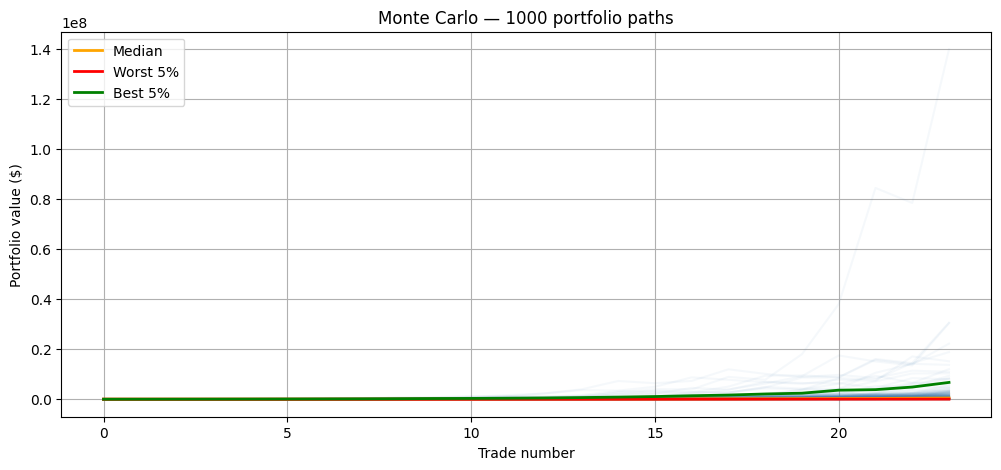

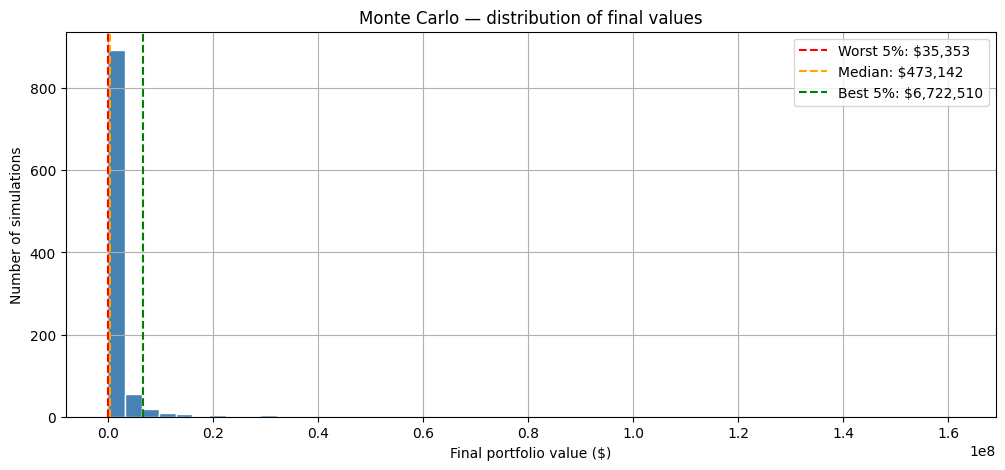

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Use MEDIAN instead of average to avoid outlier distortion
win_rate = 0.519
median_win = 0.575      # +57.5% realistic win
median_loss = -0.091    # -9.1% realistic loss
win_std = 0.45          # spread around the median win
loss_std = 0.05         # spread around the median loss
n_trades = 23
starting_capital = 10000
n_simulations = 1000

simulation_results = []
all_paths = []

for i in range(n_simulations):
    capital = starting_capital
    path = [capital]

    for t in range(n_trades):
        if np.random.random() < win_rate:
            r = np.random.normal(median_win, win_std)
            r = max(r, -0.99)  # can't lose more than 99%
        else:
            r = np.random.normal(median_loss, loss_std)
            r = max(r, -0.99)

        capital = capital * (1 + r)
        capital = max(capital, 0)
        path.append(capital)

    simulation_results.append(capital)
    all_paths.append(path)

simulation_results = np.array(simulation_results)

# Print results
print("--- MONTE CARLO RESULTS (1000 simulations) ---")
print(f"Starting capital:         ${starting_capital:,.2f}")
print(f"")
print(f"Median final value:       ${np.percentile(simulation_results, 50):,.2f}")
print(f"Best case (95th %):       ${np.percentile(simulation_results, 95):,.2f}")
print(f"Worst case (5th %):       ${np.percentile(simulation_results, 5):,.2f}")
print(f"")
print(f"Chance of profit:         {(simulation_results > starting_capital).mean()*100:.1f}%")
print(f"Chance of doubling:       {(simulation_results > starting_capital*2).mean()*100:.1f}%")
print(f"Chance of losing half:    {(simulation_results < starting_capital*0.5).mean()*100:.1f}%")
print(f"Chance of 10x:            {(simulation_results > starting_capital*10).mean()*100:.1f}%")

# Chart 1 - all paths
plt.figure(figsize=(12, 5))
for path in all_paths[:200]:
    plt.plot(path, alpha=0.05, color='steelblue')
median_path = [np.percentile([p[i] for p in all_paths], 50)
               for i in range(n_trades+1)]
worst_path = [np.percentile([p[i] for p in all_paths], 5)
              for i in range(n_trades+1)]
best_path = [np.percentile([p[i] for p in all_paths], 95)
             for i in range(n_trades+1)]
plt.plot(median_path, color='orange', linewidth=2, label='Median')
plt.plot(worst_path, color='red', linewidth=2, label='Worst 5%')
plt.plot(best_path, color='green', linewidth=2, label='Best 5%')
plt.title("Monte Carlo — 1000 portfolio paths")
plt.xlabel("Trade number")
plt.ylabel("Portfolio value ($)")
plt.legend()
plt.grid(True)
plt.show()

# Chart 2 - final value distribution
plt.figure(figsize=(12, 5))
plt.hist(simulation_results, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.percentile(simulation_results, 5), color='red',
            linestyle='--', label=f"Worst 5%: ${np.percentile(simulation_results, 5):,.0f}")
plt.axvline(np.percentile(simulation_results, 50), color='orange',
            linestyle='--', label=f"Median: ${np.percentile(simulation_results, 50):,.0f}")
plt.axvline(np.percentile(simulation_results, 95), color='green',
            linestyle='--', label=f"Best 5%: ${np.percentile(simulation_results, 95):,.0f}")
plt.title("Monte Carlo — distribution of final values")
plt.xlabel("Final portfolio value ($)")
plt.ylabel("Number of simulations")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
wins = closed_trades[closed_trades['Return'] > 0]['Return']
losses = closed_trades[closed_trades['Return'] < 0]['Return']

print(f"Avg win:    {wins.mean()*100:.1f}%")
print(f"Median win: {wins.median()*100:.1f}%")
print(f"Avg loss:   {losses.mean()*100:.1f}%")
print(f"Median loss:{losses.median()*100:.1f}%")
print(f"")
print(f"Individual wins:")
print(wins.sort_values().values * 100)

Avg win:    215.1%
Median win: 57.5%
Avg loss:   -12.1%
Median loss:-9.1%

Individual wins:
[  2.46103554   8.51596272   9.98648257  33.70566207  40.14219848
  57.45238273 174.80423949 186.50120281 402.71219383 515.04924823
 934.34461248]
